
# Week 4 — API Development, Evaluation & Final Delivery

In [1]:
!pip install scikit-learn pandas numpy matplotlib seaborn joblib fastapi uvicorn nest-asyncio

## Step-1 Import Libraries 

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

print(' All libraries loaded!')

 All libraries loaded!


## Step- 2 Load Dataset

In [16]:
# Load dataset
# Upload processed_grievances.csv to Colab before running this cell
df = pd.read_csv('processed_grievances.csv')

#Rename 'product' column to 'department' for clarity
df = df.rename(columns={'product': 'department'})

# Drop rows with missing processed_text
df = df.dropna(subset=['processed_text'])
df['processed_text'] = df['processed_text'].astype(str)

print(f' Dataset loaded: {df.shape[0]:,} rows')
print(f'Columns: {list(df.columns)}')
print(f'\nDepartment distribution:')
print(df['department'].value_counts())

 Dataset loaded: 162,421 rows
Columns: ['Unnamed: 0', 'department', 'narrative', 'text_length', 'word_count', 'cleaned_text', 'processed_text']

Department distribution:
department
credit_reporting       91179
debt_collection        23150
mortgages_and_loans    18990
credit_card            15566
retail_banking         13536
Name: count, dtype: int64


In [17]:
# Use a stratified sample for faster training (use full data if GPU available)
df_sample = df.groupby('department', group_keys=False).apply(
    lambda x: x.sample(min(len(x), 3000), random_state=42)
).reset_index(drop=True)

print(f' Sampled dataset: {len(df_sample):,} rows')
print(df_sample['department'].value_counts())

 Sampled dataset: 15,000 rows
department
credit_card            3000
credit_reporting       3000
debt_collection        3000
mortgages_and_loans    3000
retail_banking         3000
Name: count, dtype: int64


---
## Step- 3 Add Synthetic Sentiment Labels
> Since the dataset doesn't have sentiment labels, we'll assign them based on urgency keywords — a common real-world NLP technique called rule-based pre-labeling.

Sentiment labels assigned!
sentiment
Negative    5629
Critical    5198
Neutral     3742
Positive     431
Name: count, dtype: int64


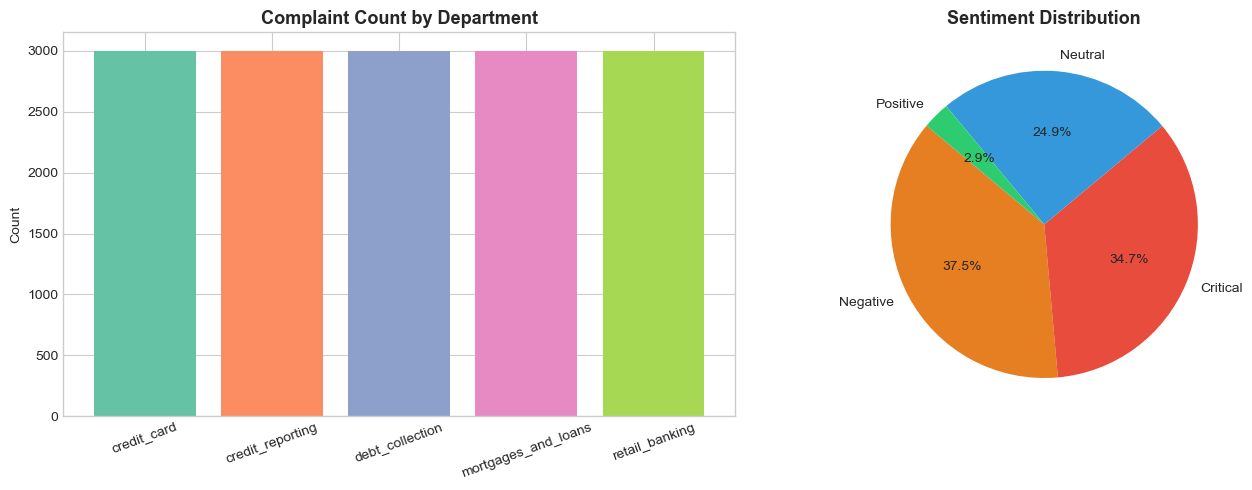

In [18]:
def assign_sentiment(text):
    """Assign sentiment based on urgency keywords in the complaint text."""
    text = str(text).lower()
    
    critical_keywords = [
        'fraud', 'stolen', 'illegal', 'lawsuit', 'attorney', 'court',
        'emergency', 'urgent', 'immediately', 'criminal', 'scam', 'harassment'
    ]
    negative_keywords = [
        'wrong', 'error', 'problem', 'issue', 'complaint', 'denied',
        'unfair', 'incorrect', 'failed', 'refuse', 'never', 'worst',
        'terrible', 'horrible', 'angry', 'frustrated', 'disappoint'
    ]
    positive_keywords = [
        'thank', 'great', 'good', 'excellent', 'resolved', 'happy',
        'satisfied', 'appreciate', 'helpful', 'perfect', 'wonderful'
    ]
    
    if any(word in text for word in critical_keywords):
        return 'Critical'
    elif any(word in text for word in negative_keywords):
        return 'Negative'
    elif any(word in text for word in positive_keywords):
        return 'Positive'
    else:
        return 'Neutral'

df_sample['sentiment'] = df_sample['narrative'].apply(assign_sentiment)

print('Sentiment labels assigned!')
print(df_sample['sentiment'].value_counts())

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dept_counts = df_sample['department'].value_counts()
axes[0].bar(dept_counts.index, dept_counts.values, color=sns.color_palette('Set2'))
axes[0].set_title('Complaint Count by Department', fontsize=13, fontweight='bold')
axes[0].tick_params(axis='x', rotation=20)
axes[0].set_ylabel('Count')

sent_counts = df_sample['sentiment'].value_counts()
colors = {'Critical': '#e74c3c', 'Negative': '#e67e22', 'Neutral': '#3498db', 'Positive': '#2ecc71'}
axes[1].pie(
    sent_counts.values,
    labels=sent_counts.index,
    autopct='%1.1f%%',
    colors=[colors.get(s, 'grey') for s in sent_counts.index],
    startangle=140
)
axes[1].set_title('Sentiment Distribution', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

## Step- 4 Train-Test-Split

In [20]:
X = df_sample['processed_text']
y_dept = df_sample['department']
y_sent = df_sample['sentiment']

# Split for department classifier
X_train, X_test, y_dept_train, y_dept_test = train_test_split(
    X, y_dept, test_size=0.2, random_state=42, stratify=y_dept
)

# Split for sentiment classifier (same indices)
_, _, y_sent_train, y_sent_test = train_test_split(
    X, y_sent, test_size=0.2, random_state=42, stratify=y_sent
)

print(f' Train set: {len(X_train):,} samples')
print(f' Test set:  {len(X_test):,} samples')

 Train set: 12,000 samples
 Test set:  3,000 samples



## Step- 5 Department Classification Model (TF-IDF + Logistic Regression)

In [25]:
#Training Department Classifier

# Build pipeline
dept_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=10000,
        ngram_range=(1, 2),
        min_df=2,
        sublinear_tf=True
    )),
    ('clf', LogisticRegression(
        max_iter=1000,
        C=1.0,
        solver='lbfgs',
        multi_class='multinomial',
        random_state=42
    ))
])

dept_pipeline.fit(X_train, y_dept_train)
y_dept_pred = dept_pipeline.predict(X_test)

dept_acc = accuracy_score(y_dept_test, y_dept_pred)
dept_f1  = f1_score(y_dept_test, y_dept_pred, average='macro')

print(f' Department Classifier Results:')
print(f'   Accuracy:   {dept_acc:.4f} ({dept_acc*100:.2f}%)')
print(f'   Macro F1:   {dept_f1:.4f}')

 Department Classifier Results:
   Accuracy:   0.8437 (84.37%)
   Macro F1:   0.8437



## Step- 6 Department Classifier Evaluation

In [26]:
# Classification Report
print('='*60)
print('DEPARTMENT CLASSIFICATION REPORT')
print('='*60)
print(classification_report(y_dept_test, y_dept_pred))

DEPARTMENT CLASSIFICATION REPORT
                     precision    recall  f1-score   support

        credit_card       0.82      0.82      0.82       600
   credit_reporting       0.81      0.81      0.81       600
    debt_collection       0.81      0.83      0.82       600
mortgages_and_loans       0.87      0.87      0.87       600
     retail_banking       0.90      0.90      0.90       600

           accuracy                           0.84      3000
          macro avg       0.84      0.84      0.84      3000
       weighted avg       0.84      0.84      0.84      3000



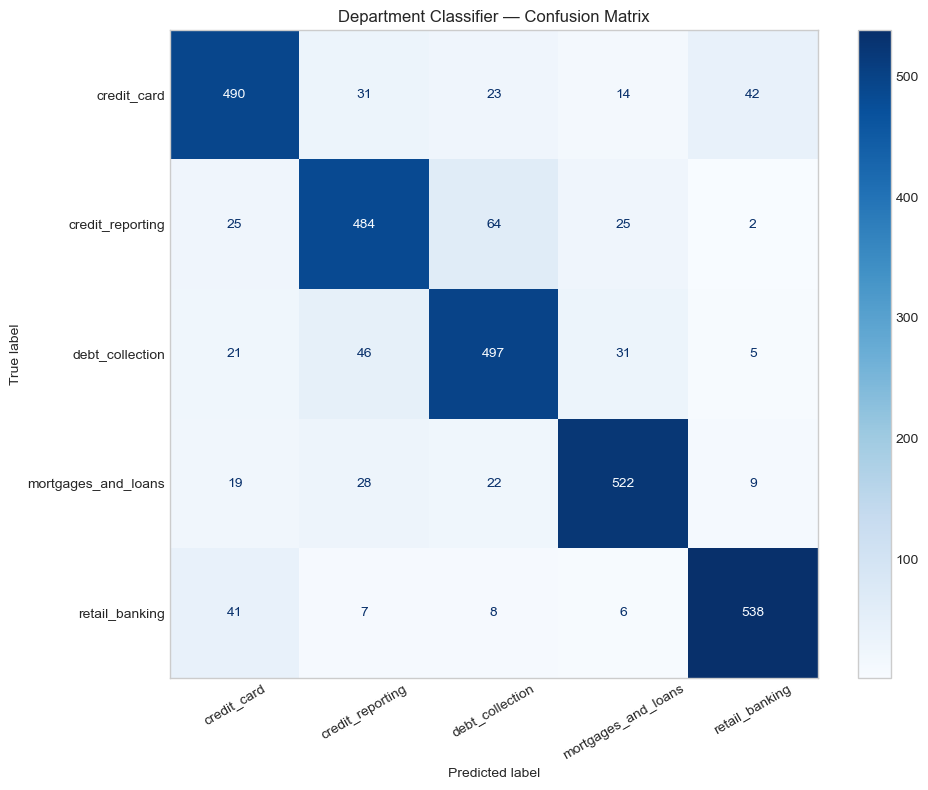

In [29]:
# Confusion Matrix
dept_labels = sorted(y_dept.unique())
cm_dept = confusion_matrix(y_dept_test, y_dept_pred, labels=dept_labels)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_dept, display_labels=dept_labels)
disp.plot(ax=ax, cmap='Blues', xticks_rotation=30)
ax.grid(False) 
ax.set_title('Department Classifier — Confusion Matrix')
plt.tight_layout()
plt.show()

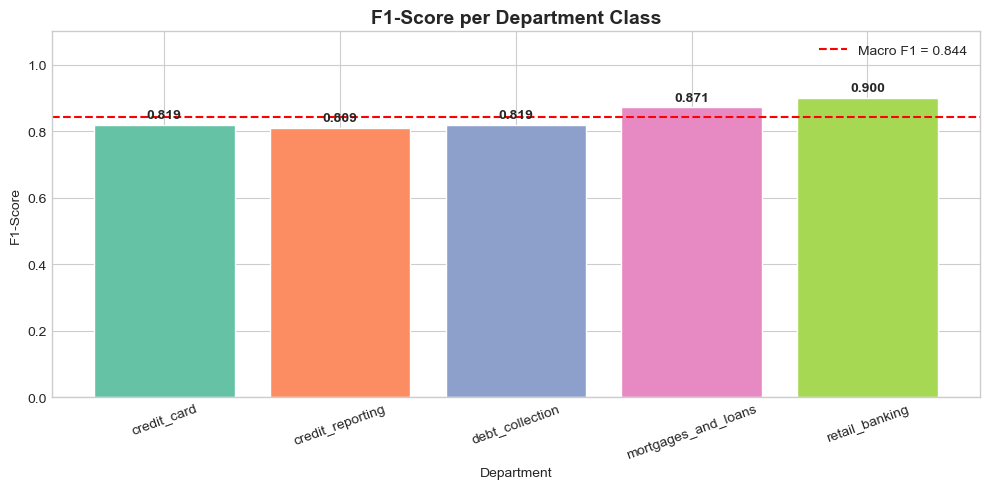

In [30]:
# Per-class F1 bar chart
report_dict = classification_report(y_dept_test, y_dept_pred, output_dict=True)
classes = [k for k in report_dict if k not in ['accuracy', 'macro avg', 'weighted avg']]
f1_scores = [report_dict[c]['f1-score'] for c in classes]

plt.figure(figsize=(10, 5))
bars = plt.bar(classes, f1_scores, color=sns.color_palette('Set2', len(classes)), edgecolor='white')
plt.axhline(y=dept_f1, color='red', linestyle='--', linewidth=1.5, label=f'Macro F1 = {dept_f1:.3f}')
plt.title('F1-Score per Department Class', fontsize=14, fontweight='bold')
plt.xlabel('Department')
plt.ylabel('F1-Score')
plt.ylim(0, 1.1)
plt.legend()
for bar, score in zip(bars, f1_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{score:.3f}', ha='center', fontsize=10, fontweight='bold')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


##  Step- 7 Sentiment Analysis Model

In [32]:
# Training Sentiment Classifier

sent_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=10000,
        ngram_range=(1, 2),
        min_df=2,
        sublinear_tf=True
    )),
    ('clf', LogisticRegression(
        max_iter=1000,
        C=1.0,
        class_weight='balanced',   # handles class imbalance
        solver='lbfgs',
        multi_class='multinomial',
        random_state=42
    ))
])

sent_pipeline.fit(X_train, y_sent_train)
y_sent_pred = sent_pipeline.predict(X_test)

sent_acc = accuracy_score(y_sent_test, y_sent_pred)
sent_f1  = f1_score(y_sent_test, y_sent_pred, average='macro')

print(f'Sentiment Classifier Results:')
print(f'   Accuracy:   {sent_acc:.4f} ({sent_acc*100:.2f}%)')
print(f'   Macro F1:   {sent_f1:.4f}')

Sentiment Classifier Results:
   Accuracy:   0.3190 (31.90%)
   Macro F1:   0.2524


In [34]:
# Sentiment Classification Report
print('='*60)
print('SENTIMENT CLASSIFICATION REPORT')
print('='*60)
print(classification_report(y_sent_test, y_sent_pred))

SENTIMENT CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Critical       0.37      0.36      0.36      1040
    Negative       0.37      0.32      0.35      1126
     Neutral       0.26      0.30      0.28       748
    Positive       0.02      0.03      0.02        86

    accuracy                           0.32      3000
   macro avg       0.26      0.25      0.25      3000
weighted avg       0.33      0.32      0.33      3000



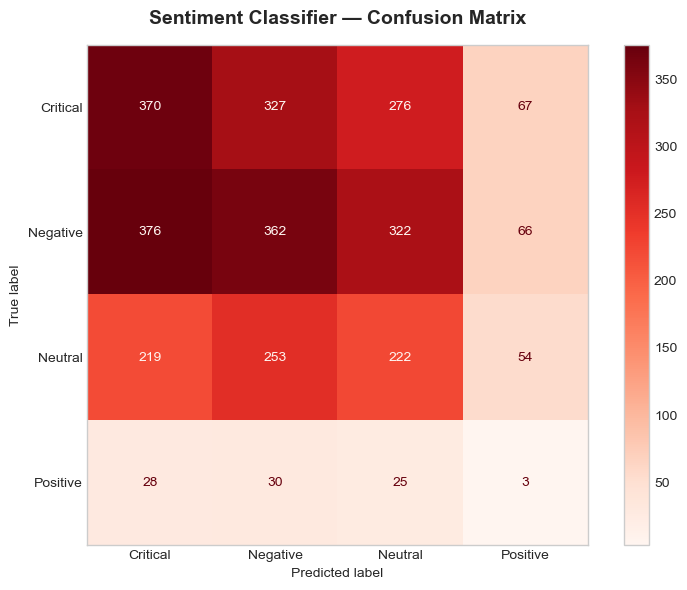

In [36]:
# Sentiment Confusion Matrix
sent_labels = sorted(y_sent.unique())
cm_sent = confusion_matrix(y_sent_test, y_sent_pred, labels=sent_labels)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_sent, display_labels=sent_labels)
disp.plot(ax=ax, cmap='Reds', colorbar=True)
ax.grid(False)
ax.set_title('Sentiment Classifier — Confusion Matrix', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


## Step- 8 Priority Score Assignment

In [38]:
PRIORITY_MAP = {
    'Critical': 1.0,
    'Negative': 0.65,
    'Neutral':  0.35,
    'Positive': 0.10
}

def get_priority_score(sentiment: str, confidence: float) -> float:
    """Compute weighted priority score from sentiment class and model confidence."""
    base_score = PRIORITY_MAP.get(sentiment, 0.35)
    return round(base_score * confidence, 4)

# Demo on test set
sent_probs = sent_pipeline.predict_proba(X_test)
sent_classes = sent_pipeline.classes_

sample_results = []
for i in range(5):
    pred_sentiment  = y_sent_pred[i]
    confidence      = sent_probs[i].max()
    priority_score  = get_priority_score(pred_sentiment, confidence)
    pred_dept       = y_dept_pred[i]
    sample_results.append({
        'text_snippet'    : X_test.iloc[i][:60] + '...',
        'dept_predicted'  : pred_dept,
        'sentiment'       : pred_sentiment,
        'confidence'      : round(float(confidence), 4),
        'priority_score'  : priority_score
    })

results_df = pd.DataFrame(sample_results)
print(' Sample Predictions with Priority Scores:')
print(results_df.to_string(index=False))

 Sample Predictions with Priority Scores:
                                                   text_snippet   dept_predicted sentiment  confidence  priority_score
today deposit check amount dollar deposited check bank ameri...   retail_banking  Negative      0.3596          0.2338
contact via online chat message ask could start cellular ser...  debt_collection  Negative      0.3212          0.2088
account list credit report never open account information us... credit_reporting  Negative      0.4677          0.3040
cfpb jurisdiction matter pertain credit reporting issue comm...      credit_card  Positive      0.4975          0.0498
xxxxy report debt credit report mine account fraud account m...  debt_collection  Negative      0.3465          0.2252


---
## Step- 9 Save (Serialize) Models
> **Note:** Add `*.pkl` to your `.gitignore` — never push model files to GitHub.

In [39]:
os.makedirs('models', exist_ok=True)

# Save department pipeline
joblib.dump(dept_pipeline, 'models/dept_classifier.pkl')
print(' Department model saved → models/dept_classifier.pkl')

# Save sentiment pipeline
joblib.dump(sent_pipeline, 'models/sent_classifier.pkl')
print(' Sentiment model saved → models/sent_classifier.pkl')

# Save priority map
with open('models/priority_map.json', 'w') as f:
    json.dump(PRIORITY_MAP, f, indent=2)
print(' Priority map saved → models/priority_map.json')

# Verify files
print('\n Saved model files:')
for f in os.listdir('models'):
    size = os.path.getsize(f'models/{f}')
    print(f'   {f}  ({size/1024:.1f} KB)')

 Department model saved → models/dept_classifier.pkl
 Sentiment model saved → models/sent_classifier.pkl
 Priority map saved → models/priority_map.json

 Saved model files:
   dept_classifier.pkl  (790.5 KB)
   priority_map.json  (0.1 KB)
   sent_classifier.pkl  (712.3 KB)
